In [5]:
import numpy as np
import partimorph as pm

### Analysis and Sorting by Sphericity
All masks are analyzed and then sorted by their **Sphericity** value in descending order.
The plot title now includes the **Aspect Ratio** (Major/Minor) from ellipse fitting.

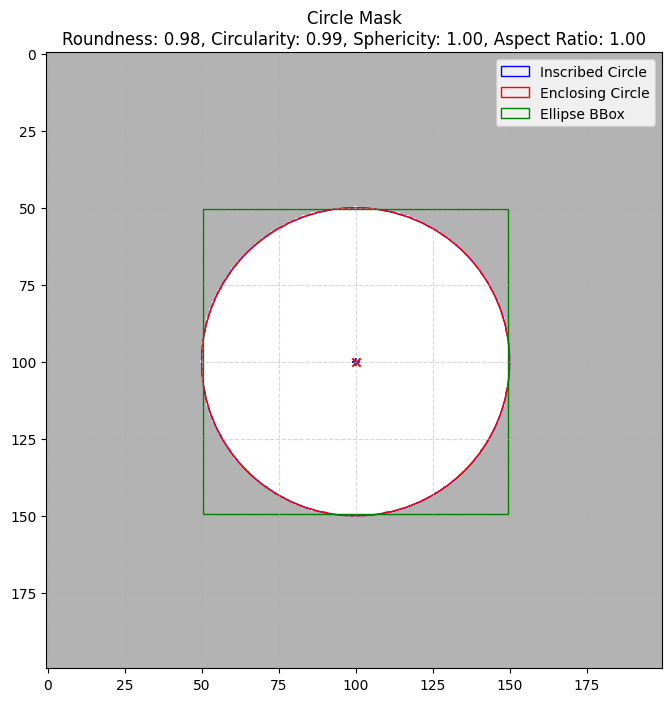

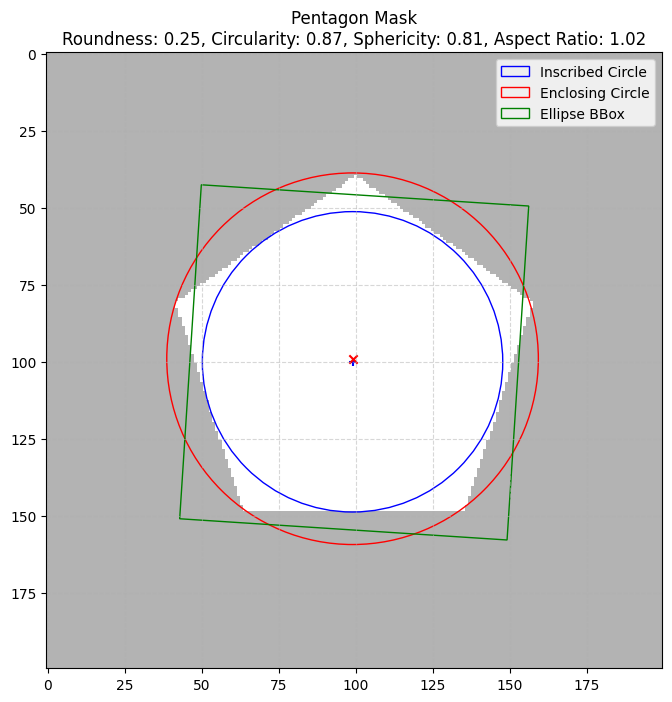

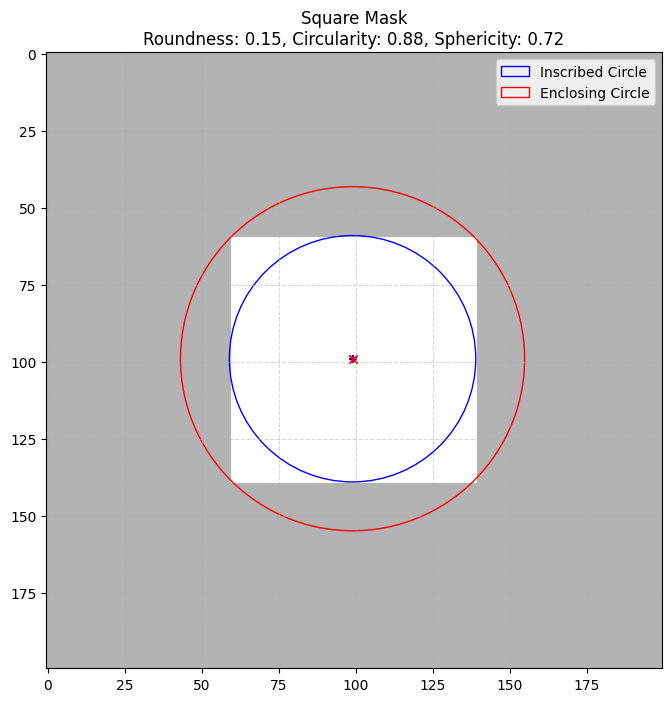

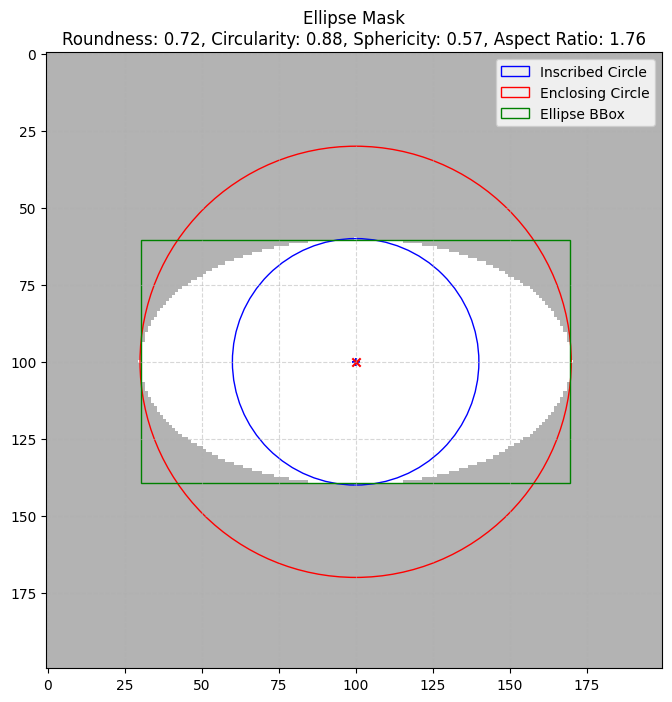

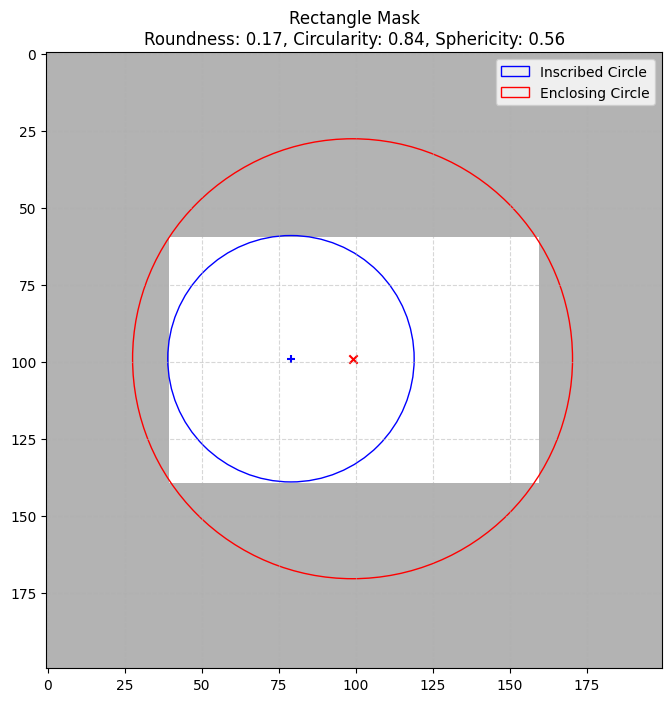

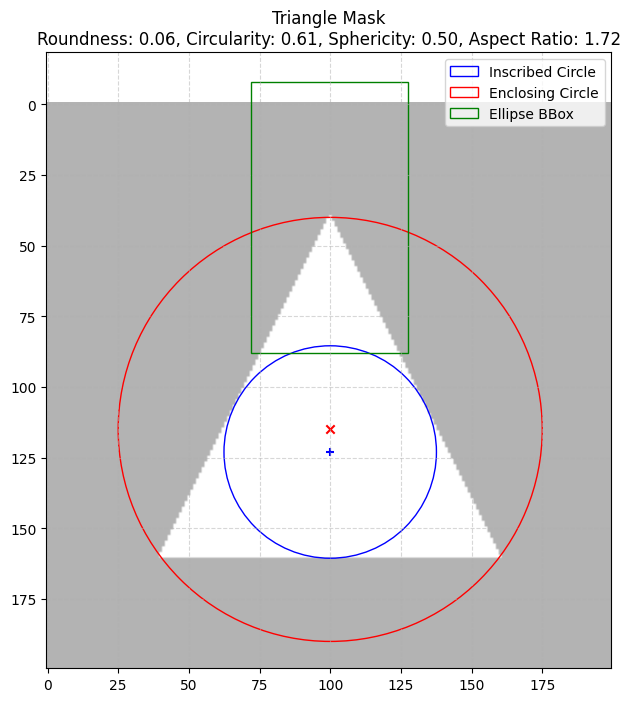

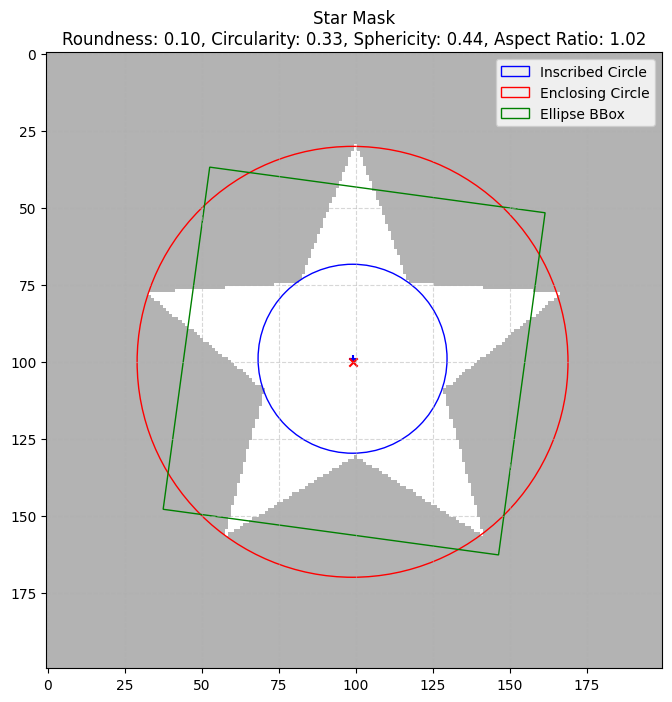

In [6]:
shape = (200, 200)
masks_to_process = [
    ("Circle", pm.utils.create_circle_mask(shape, center=(100, 100), radius=50)),
    ("Ellipse", pm.utils.create_ellipse_mask(shape, center=(100, 100), radius_x=70, radius_y=40)),
    ("Rectangle", pm.utils.create_rectangle_mask(shape, top_left=(60, 40), bottom_right=(140, 160))),
    ("Square", pm.utils.create_square_mask(shape, top_left=(60, 60), size=80)),
    ("Triangle", pm.utils.create_triangle_mask(shape, v1=(40, 160), v2=(160, 160), v3=(100, 40))),
    ("Pentagon", pm.utils.create_pentagon_mask(shape, center=(100, 100), radius=60)),
    ("Star", pm.utils.create_star_mask(shape, center=(100, 100), outer_radius=70, inner_radius=30)),
]

# 1. Analyze all masks
results_list = []
for name, mask in masks_to_process:
    res = pm.analyze_mask(mask)
    results_list.append({
        "name": name,
        "mask": mask,
        "results": res,
        "sphericity": res.get("sphericity", {}).get("val", 0.0)
    })

# 2. Sort by Sphericity (Descending)
sorted_results = sorted(results_list, key=lambda x: x["sphericity"], reverse=True)

# 3. Plot in sorted order
for item in sorted_results:
    pm.utils.plot_analysis_results(
        mask = item["mask"],
        results = item["results"],
        title_prefix = f"{item['name']} Mask",
    )

# Parametric Mask Test

This notebook exercises create_fourier_particle_mask with basic metrics.


In [7]:
import numpy as np

from partimorph.analyzer import analyze_mask
from partimorph.utils import create_fourier_particle_mask, plot_analysis_results


{'sphericity_target': 0.75, 'roundness_target': 0.8, 'roundness_metric': 'wadell', 'roundness_achieved': 0.7914472699044676, 'amplitude': 0.07679443359375, 'frequencies': array([2, 3, 4, 5, 6, 7, 8]), 'phases': array([5.24462068, 5.01827773, 4.16663281, 5.43525716, 2.19156621,
       0.55982775, 2.63126073])}
{'ellipse': {'val': 1.3816721909842113, 'major': 144.08253479003906, 'minor': 104.2812728881836, 'bbox': array([[ 60.59376 ,  69.26074 ],
       [204.06494 ,  82.51962 ],
       [194.46867 , 186.35843 ],
       [ 50.997498, 173.09955 ]], dtype=float32)}, 'roundness': {'val': 0.7914472699044676}, 'circularity': {'val': 0.959510189420393}, 'sphericity': {'val': 0.7355846277328195, 'inscribed': {'x': 122, 'y': 127, 'r': 52.0}, 'enclosing': {'x': 129, 'y': 129, 'r': 70.69207000732422}}}


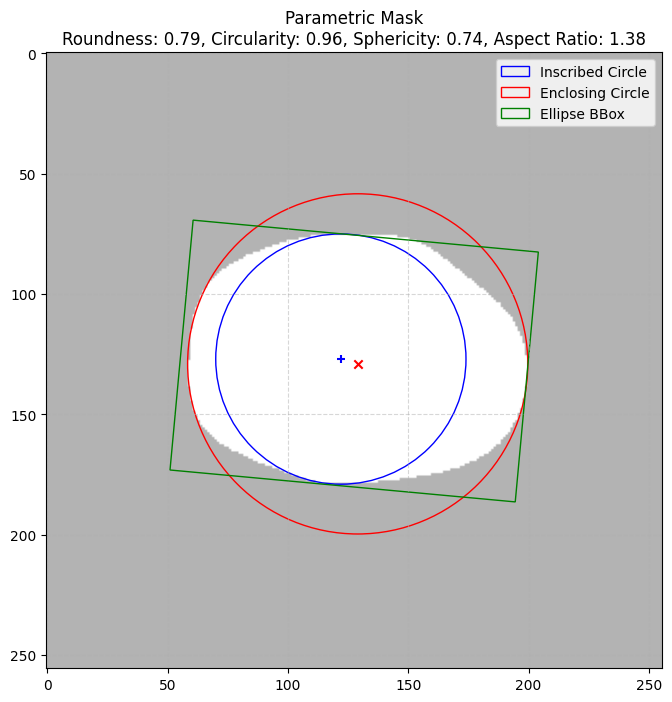

In [13]:
mask, info = create_fourier_particle_mask(
    shape=(256, 256),
    center=(128, 128),
    sphericity=0.75,
    roundness=0.8,
    base_radius=70,
    metric="wadell",
    seed=None,
    return_info=True,
)

results = analyze_mask(mask)
print(info)
print(results)

plot_analysis_results(mask, results, title_prefix="Parametric Mask")
